#Convolutional Neural  Network for image classification

#importing the libraries

In [ ]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile
from google.colab.patches import cv2_imshow
tf.__version__



'2.19.0'

#loading the image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Datasets/homer_bart_2.zip'

In [ ]:
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

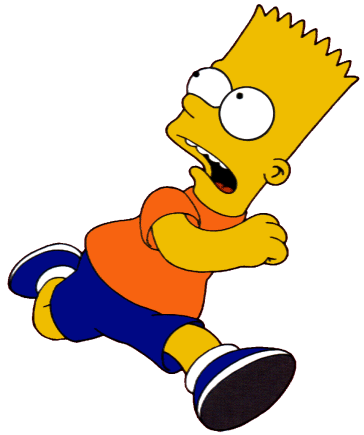

In [ ]:
tf.keras.preprocessing.image.load_img('/content/homer_bart_2/training_set/bart/bart100.bmp')

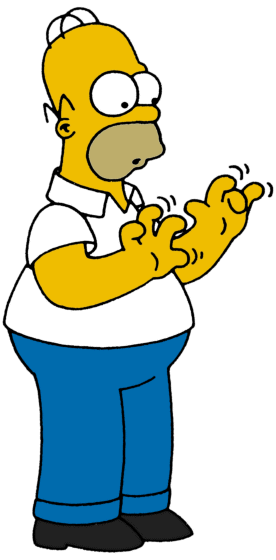

In [ ]:
tf.keras.preprocessing.image.load_img('/content/homer_bart_2/training_set/homer/homer100.bmp')

#Creating train and tast **sets**

In [ ]:
traning_generator =ImageDataGenerator(rescale=1/255,
                                        rotation_range =7,
                                        horizontal_flip=True,
                                        zoom_range=0.2)


In [ ]:
train_dataset = traning_generator.flow_from_directory('/content/homer_bart_2/training_set',
                                                      target_size=(64,64),
                                                      batch_size=8,
                                                      class_mode='categorical',
                                                      shuffle=True)

Found 215 images belonging to 2 classes.


In [ ]:
train_dataset.class_indices

{'bart': 0, 'homer': 1}

In [ ]:
test_generator = ImageDataGenerator(rescale=1/255)
test_dataset = test_generator.flow_from_directory('/content/homer_bart_2/test_set',
                                                  target_size=(64,64),
                                                      batch_size=1,
                                                      class_mode='categorical',
                                                      shuffle=False)


Found 54 images belonging to 2 classes.


In [ ]:
test_dataset.class_indices

{'bart': 0, 'homer': 1}

#Building and Training neural network

In [ ]:
train_dataset.image_shape

(64, 64, 3)

In [ ]:
network = Sequential()
network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(64,64,3)))
network.add(MaxPool2D(pool_size=(2,2)))

network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
network.add(MaxPool2D(pool_size=(2,2)))

network.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
network.add(MaxPool2D(pool_size=(2,2)))

network.add(Flatten())
network.add(Dense(units=577, activation='relu'))
network.add(Dense(units=577, activation='relu'))
network.add(Dense(units=2, activation='softmax'))
network.summary()





/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 577)            │       665,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 577)            │       333,506 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         1,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,019,335 (3.89 MB)

 Trainable params: 1,019,335 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
network.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history=network.fit(train_dataset, epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5427 - loss: 0.7770
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6575 - loss: 0.6065
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7481 - loss: 0.4759
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7859 - loss: 0.4773
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8486 - loss: 0.4231
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8291 - loss: 0.3786
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9039 - loss: 0.2862
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8776 - loss: 0.2924
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9181 - loss: 0.2312
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8882 - loss: 0.2529
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9286 - loss: 0.2718
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9146 - l

#Evaluating the neural network

In [ ]:
predections = network.predict(test_dataset)
predections

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[1.0000000e+00, 1.7468365e-18],
       [1.0000000e+00, 5.6204114e-10],
       [7.7988970e-01, 2.2011031e-01],
       [1.0000000e+00, 1.0269524e-16],
       [1.0000000e+00, 4.5535994e-24],
       [1.0000000e+00, 2.7384236e-13],
       [1.0000000e+00, 2.0546693e-09],
       [9.7345102e-01, 2.6549015e-02],
       [2.9243387e-02, 9.7075665e-01],
       [9.3612921e-01, 6.3870803e-02],
       [9.7248638e-01, 2.7513655e-02],
       [1.0000000e+00, 1.4776900e-15],
       [8.4477526e-01, 1.5522480e-01],
       [9.8561698e-01, 1.4382991e-02],
       [9.9975294e-01, 2.4701588e-04],
       [1.0000000e+00, 1.5352369e-14],
       [9.9998939e-01, 1.0641151e-05],
       [1.0000000e+00, 3.1087988e-13],
       [7.6671267e-01, 2.3328727e-01],
       [1.0000000e+00, 1.0742120e-21],
       [9.1552013e-01, 8.4479846e-02],
       [1.0000000e+00, 5.9875848e-15],
       [9.9999321e-01, 6.7363744e-06],
       [8.1402594e-01, 1.8597409e-01],
       [1.0000000e+00, 3.9832188e-10],
       [9.9787796e-01, 2.

In [ ]:
predections = np.argmax(predections, axis=1)
predections

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
test_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(test_dataset.classes, predections)


0.9629629629629629

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_dataset.classes, predections)
cm

array([[27,  1],
       [ 1, 25]])

<Axes: >

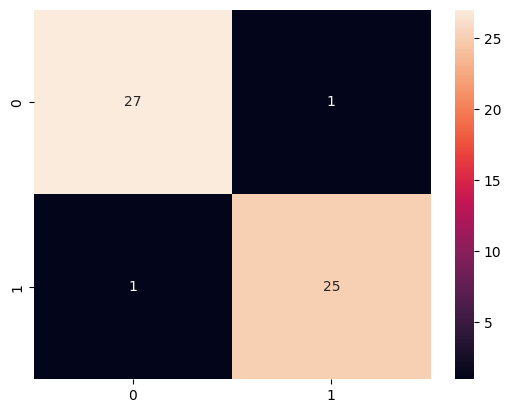

In [ ]:
sns.heatmap(cm, annot=True)

In [ ]:
from sklearn.metrics import classification_report
cr = classification_report(test_dataset.classes, predections)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.96      0.96      0.96        26

    accuracy                           0.96        54
   macro avg       0.96      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



#Saveing and loading model

In [ ]:
model_json = network.to_json()
with open('model.json', 'w') as json_file:
  json_file.write(model_json)

In [ ]:
from tensorflow.keras.models import save_model
network_saved = save_model(network,'/content/weights.hdf5')

In [ ]:
from posixpath import join
with open('model.json', 'r') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 64, 64, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Conv2D", "config": {"name": "conv2d", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "valid", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module":

In [ ]:
network_loaded=tf.keras.models.model_from_json(json_saved_model)
network_loaded.load_weights('/content/weights.hdf5')
network_loaded.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Classifying one single image

In [ ]:
image = cv2.imread('/content/homer_bart_2/test_set/bart/bart10.bmp')

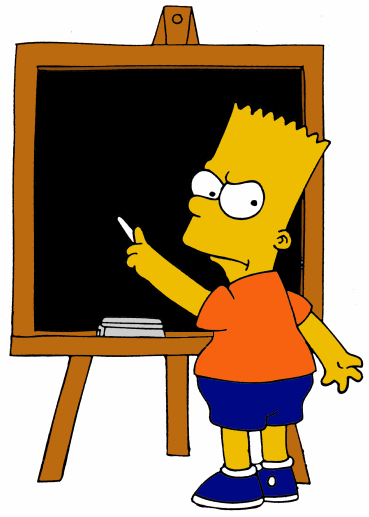

In [ ]:
cv2_imshow(image)

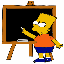

In [ ]:
image = cv2.resize(image, (64,64))
cv2_imshow(image)

In [ ]:
image = image.reshape(1,64,64,3)
image.shape

(1, 64, 64, 3)

In [ ]:
rsualt = network_loaded.predict(image)
rsualt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[1., 0.]], dtype=float32)

In [ ]:
rsualt = np.argmax(rsualt)
rsualt

np.int64(0)

In [ ]:
if rsualt == 0:
  print('bart')
else:
  print('homer')

bart


#Homework

In [ ]:
path = '/content/drive/MyDrive/Datasets/cat_dog_2.zip'
zip_object = zipfile.ZipFile(file = path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [ ]:
traning_generator=ImageDataGenerator(rescale=1/255,
                                        rotation_range =7,
                                        horizontal_flip=True,
                                        zoom_range=0.2)

In [ ]:
train_dataset=test_generator.flow_from_directory('/content/cat_dog_2/training_set',
                                                      target_size=(64,64),
                                                      batch_size=8,
                                                      class_mode='categorical',
                                                      shuffle=True)

Found 4000 images belonging to 2 classes.


In [ ]:
test_generator=ImageDataGenerator(rescale=1/255)
test_dataset=test_generator.flow_from_directory('/content/cat_dog_2/test_set',
                                                target_size=(64,64),
                                                batch_size=1,
                                                class_mode='categorical',
                                                shuffle=False)

Found 1000 images belonging to 2 classes.


In [ ]:
train_dataset.image_shape

(64, 64, 3)

In [ ]:
network2=Sequential()
network2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(64,64,3)))
network2.add(MaxPool2D(pool_size=(2,2)))

network2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
network2.add(MaxPool2D(pool_size=(2,2)))

network2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
network2.add(MaxPool2D(pool_size=(2,2)))

network2.add(Flatten())
network2.add(Dense(units=577, activation='relu'))
network2.add(Dense(units=577, activation='relu'))
network2.add(Dense(units=2, activation='softmax'))
network2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 577)            │       665,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 577)            │       333,506 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,019,335 (3.89 MB)

 Trainable params: 1,019,335 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
network2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history=network2.fit(train_dataset, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5106 - loss: 0.6980
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.5105 - loss: 0.6936
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6051 - loss: 0.6711
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6399 - loss: 0.6319
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6701 - loss: 0.6054
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7051 - loss: 0.5665
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.7495 - loss: 0.5052
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.7828 - loss: 0.4592
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.8450 - loss: 0.3616
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.8722 - loss: 0.2860


In [ ]:
predections=network2.predict(test_dataset)
predections

   1/1000 ━━━━━━━━━━━━━━━━━━━━ 2:04 125ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


array([[0.9651096 , 0.03489041],
       [0.10077885, 0.8992212 ],
       [0.02944568, 0.97055435],
       ...,
       [0.1495668 , 0.85043323],
       [0.6911375 , 0.3088625 ],
       [0.00448185, 0.99551815]], dtype=float32)

In [ ]:
predections = np.argmax(predections, axis=1)
predections

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
test_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
test_dataset.class_indices

{'cat': 0, 'dog': 1}

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(test_dataset.classes, predections)

0.688

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(test_dataset.classes, predections)
cm

array([[401,  99],
       [213, 287]])

<Axes: >

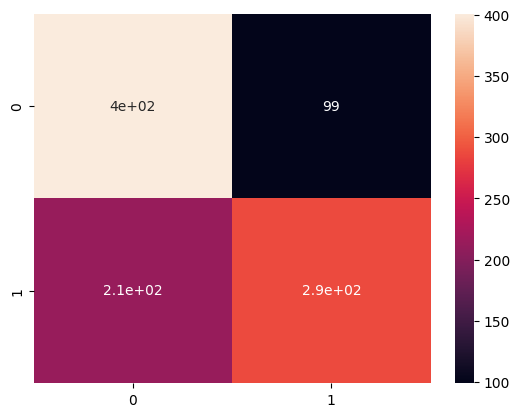

In [ ]:
sns.heatmap(cm, annot=True)

In [ ]:
from sklearn.metrics import classification_report
cr=classification_report(test_dataset.classes, predections)
print(cr)

              precision    recall  f1-score   support

           0       0.65      0.80      0.72       500
           1       0.74      0.57      0.65       500

    accuracy                           0.69      1000
   macro avg       0.70      0.69      0.68      1000
weighted avg       0.70      0.69      0.68      1000



In [ ]:
test_image='/content/cat_dog_2/test_set/cat/cat.3500.jpg'

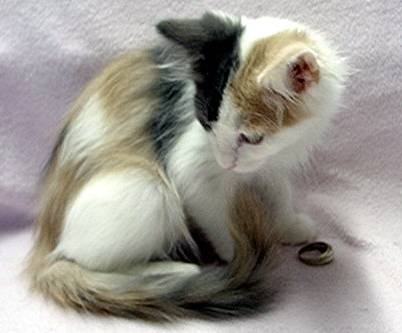

In [ ]:
cv2_imshow(cv2.imread(test_image))

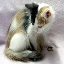

In [ ]:
image=cv2.resize(test_image, (64,64))
cv2_imshow(image)